In [43]:
import mosaique as mq
from concurrent.futures import ProcessPoolExecutor, as_completed
import itertools
import numpy as np
import pennylane as qml
import os
from mosaique.models.operation import OperationLayer
from tensorflow import keras

In [44]:

# Set the environment for asynchronous GPU usage
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

In [45]:
def operation():
    dev = qml.device("default.qubit.tf", wires=4)
    @qml.qnode(dev, interface='tf')
    def cnot(inputs):
        inputs = inputs * np.pi
        qml.AngleEmbedding(inputs[:,...], wires=range(4), rotation='Y')

        qml.CNOT(wires=[0, 1])
        qml.CNOT(wires=[2, 3])

        # Measurement producing 4 classical output values
        return [qml.expval(qml.PauliZ(j)) for j in range(4)]
    return cnot


In [46]:
def preset():
    from tensorflow import keras
    mnist_dataset = keras.datasets.fashion_mnist
    tr_layer = mq.ConvolutionLayer4x4("results_fashion_train")
    te_layer = mq.ConvolutionLayer4x4("results_fashion_test")
    (tr_images, tr_labels), (te_images, te_labels) = mnist_dataset.load_data()
    
    tr_images = tr_images [:50:]
    tr_labels = tr_labels[:50]
    te_images = te_images[:10:]
    te_labels = te_labels[:10]
    
    tr_layer.fit(tr_images)
    te_layer.fit(te_images)
    tr_images = tr_layer.transform(tr_images)
    te_images = te_layer.transform(te_images)
    return ((tr_layer, (tr_images, tr_labels)), (te_layer,(te_images, te_labels)))

with ProcessPoolExecutor() as executor:
    future = executor.submit(preset)

((train_layer, (train_images, train_labels)), (test_layer,(test_images, test_labels))) = future.result() #This blocks until the task completes

In [47]:

permutations = np.asarray(list(itertools.permutations(range(4))))

def pool(x, call, p, l):
    op = OperationLayer(call())
    predict = l.post_transform(op.pre_op.predict(x,batch_size=1000))
    l.save(predict, p)

In [ ]:
for j in range(3):
    with ProcessPoolExecutor(8) as executor:
        runner = {
            executor.submit(pool, x=train_images[:,:,p], call=operation, p=p, l=train_layer): p for p in permutations[8*j:8*(j+1)]
        }
        for future in as_completed(runner):
            runner.pop(future)

In [ ]:
for j in range(3):
    with ProcessPoolExecutor(8) as executor:
        runner = {
            executor.submit(pool, x=test_images[:,:,p], call=operation, p=p, l=test_layer): p for p in permutations[8*j:8*(j+1)]
        }
        for future in as_completed(runner):
            runner.pop(future)

2025-01-24 00:05:56.843786: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2025-01-24 00:05:56.937438: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2025-01-24 00:05:57.098851: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would li

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


2025-01-24 00:05:58.835344: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2025-01-24 00:05:58.857771: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2025-01-24 00:05:58.961294: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would li

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


2025-01-24 00:06:00.730987: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2025-01-24 00:06:00.812611: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2025-01-24 00:06:00.854659: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would li

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [8]:
from keras.callbacks import CSVLogger

def run(tr_images, te_images, label):
    log_dir = train_layer.name + "/run/" + label
    os.makedirs(log_dir, exist_ok=True)
    
    csv_logger = CSVLogger(log_dir)
    
    # tensorboard_callback = keras.callbacks.TensorBoard(
    #     log_dir=log_dir,
    #     histogram_freq=1,
    #     write_graph=True,
    #     write_images=True,
    #     write_steps_per_second=True,
    #     update_freq='batch',
    #     profile_batch=1,
    #     embeddings_freq=1,
    #     embeddings_metadata=None
    # )
    q_model = keras.models.Sequential([
        keras.layers.Rescaling(scale=-1. / 127.5, offset=1),
        keras.layers.Flatten(),
        keras.layers.Dense(10, activation="softmax")
    ])
    q_model.compile(
        optimizer='adam',
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    q_history = q_model.fit(
        tr_images,
        train_labels,
        validation_data=(te_images, test_labels),
        batch_size=128,
        epochs=60,
        verbose=2,
        # callbacks=[tensorboard_callback]
        callbacks = csv_logger
    )

def model(variant, tr_layer, te_layer):
    tr_images = tr_layer.open(variant)
    te_images =  te_layer.open(variant)

    label = ''.join(map(str,variant))

    run(tr_images, te_images, label)

(10, 14, 14, 4)


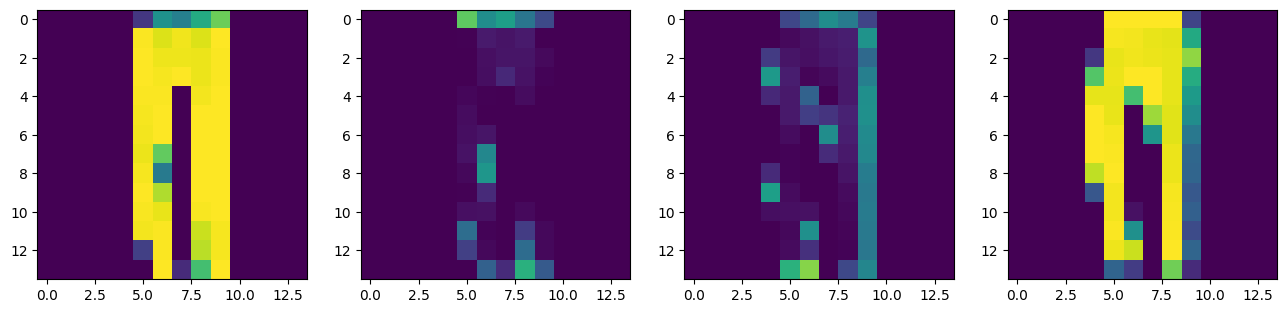

In [ ]:
from matplotlib import pyplot as plt

print(test_layer.open([0,1,3,2]).shape)

post = test_layer.open([0,1,3,2])

_min, _max = np.amin(post), np.amax(post)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Plot all output channels for quantum cnot
for c in range(4):
    axes[c].imshow(post[2,:,:,c],vmin = _min, vmax = _max)

In [21]:

# for j in range(3):
#     with ProcessPoolExecutor(8) as executor:
#         runner = {
#             executor.submit(model,variant = p, tr_layer = train_layer, te_layer= test_layer): p for p in permutations[8*j:8*(j+1)]
#         }
#         for future in as_completed(runner):
#             runner.pop(future)

2025-01-23 18:11:38.769782: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2025-01-23 18:11:39.013219: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2025-01-23 18:11:39.028191: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would li

In [ ]:
for ind, variant  in enumerate(permutations):

    label = ''.join(map(str,variant))
    # print(ind, label)
    tr_images = train_layer.open(variant)
    te_images =  test_layer.open(variant)
    run(tr_images,te_images,label)

Epoch 1/60


2025-01-24 00:16:24.786859: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


1/1 - 1s - 1s/step - accuracy: 0.0200 - loss: 3.0919 - val_accuracy: 0.0000e+00 - val_loss: 3.1124
Epoch 2/60
1/1 - 0s - 81ms/step - accuracy: 0.0200 - loss: 2.6914 - val_accuracy: 0.0000e+00 - val_loss: 3.0031
Epoch 3/60
1/1 - 0s - 58ms/step - accuracy: 0.0800 - loss: 2.3980 - val_accuracy: 0.0000e+00 - val_loss: 2.9082
Epoch 4/60
1/1 - 0s - 96ms/step - accuracy: 0.1600 - loss: 2.1726 - val_accuracy: 0.0000e+00 - val_loss: 2.8054
Epoch 5/60
1/1 - 0s - 80ms/step - accuracy: 0.3000 - loss: 1.9895 - val_accuracy: 0.0000e+00 - val_loss: 2.6899
Epoch 6/60
1/1 - 0s - 72ms/step - accuracy: 0.4200 - loss: 1.8347 - val_accuracy: 0.0000e+00 - val_loss: 2.5622
Epoch 7/60
1/1 - 0s - 74ms/step - accuracy: 0.5200 - loss: 1.6989 - val_accuracy: 0.1000 - val_loss: 2.4259
Epoch 8/60
1/1 - 0s - 77ms/step - accuracy: 0.6200 - loss: 1.5769 - val_accuracy: 0.1000 - val_loss: 2.2864
Epoch 9/60
1/1 - 0s - 63ms/step - accuracy: 0.6400 - loss: 1.4653 - val_accuracy: 0.1000 - val_loss: 2.1488
Epoch 10/60
1/1 -

In [36]:
# run the network without filter

run(train_images,test_images,"NO-FILTER")

Epoch 1/60
1/1 - 1s - 685ms/step - accuracy: 0.1200 - loss: 3.0768 - val_accuracy: 0.1000 - val_loss: 2.4823
Epoch 2/60
1/1 - 0s - 94ms/step - accuracy: 0.1600 - loss: 2.7032 - val_accuracy: 0.3000 - val_loss: 2.3765
Epoch 3/60
1/1 - 0s - 64ms/step - accuracy: 0.1600 - loss: 2.4139 - val_accuracy: 0.4000 - val_loss: 2.3105
Epoch 4/60
1/1 - 0s - 58ms/step - accuracy: 0.2600 - loss: 2.1832 - val_accuracy: 0.4000 - val_loss: 2.2474
Epoch 5/60
1/1 - 0s - 70ms/step - accuracy: 0.3400 - loss: 1.9877 - val_accuracy: 0.4000 - val_loss: 2.1707
Epoch 6/60
1/1 - 0s - 73ms/step - accuracy: 0.4400 - loss: 1.8156 - val_accuracy: 0.4000 - val_loss: 2.0717
Epoch 7/60
1/1 - 0s - 88ms/step - accuracy: 0.4600 - loss: 1.6567 - val_accuracy: 0.4000 - val_loss: 1.9535
Epoch 8/60
1/1 - 0s - 60ms/step - accuracy: 0.5000 - loss: 1.5074 - val_accuracy: 0.5000 - val_loss: 1.8264
Epoch 9/60
1/1 - 0s - 78ms/step - accuracy: 0.6000 - loss: 1.3700 - val_accuracy: 0.5000 - val_loss: 1.6999
Epoch 10/60
1/1 - 0s - 61ms

# Read Validation accuracy 
Now we will read from the csv and group the experiment validation for the last 30 epoch into the symmetries

In [13]:
# group the index of the permutation by the symmetry of the filter

diagonal_index = [4, 5, 8, 9, 14, 15, 18, 19]
vertical_index = [0, 1, 6, 7, 16, 17, 22, 23]
horizontal_index = [2, 3, 10, 11, 12, 13, 20, 21]

In [30]:
import pandas as pd

diagonal_val_accuracy = []
vertical_val_accuracy = []
horizontal_val_accuracy = []

for ind, variant  in enumerate(permutations):
    label = ''.join(map(str,variant))
    # print(label)
    file = train_layer.name + "/run/" + label
    # print(file)
    
    #read the csv file
    df = pd.read_csv(file)
    
    if ind in diagonal_index:
        diagonal_val_accuracy.append(df['val_accuracy'].tail(30).tolist())
        
    elif ind in vertical_index:
        vertical_val_accuracy.append(df['val_accuracy'].tail(30).tolist())
    
    elif ind in horizontal_index:
        horizontal_val_accuracy.append(df['val_accuracy'].tail(30).tolist())


In [ ]:
# need to flatten the list to have all the data in a single list
diagonal_val_accuracy_flattened = [item for sublist in diagonal_val_accuracy for item in sublist]
vertical_val_accuracy_flattened = [item for sublist in vertical_val_accuracy for item in sublist]
horizontal_val_accuracy_flattened = [item for sublist in horizontal_val_accuracy for item in sublist]


In [37]:
file = train_layer.name + "/run/" + "NO-FILTER"
df = pd.read_csv(file)
no_fitler_val_accuracy = df['val_accuracy'].tail(30).tolist()

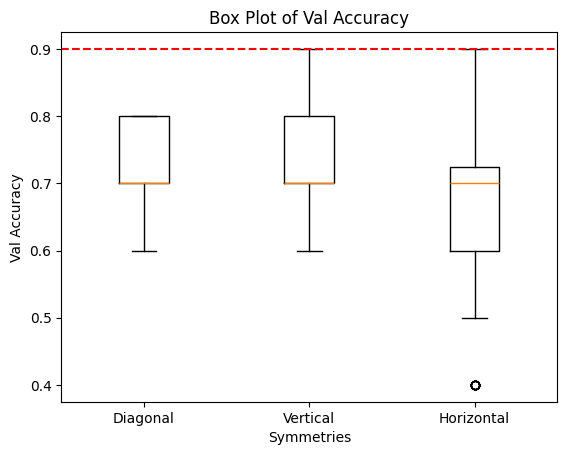

In [ ]:
import matplotlib.pyplot as plt

# Combine the data into a list of lists
data = [diagonal_val_accuracy_flattened, vertical_val_accuracy_flattened, horizontal_val_accuracy_flattened]

# Define the labels for the box plot
labels_plot = ['Diagonal', 'Vertical', 'Horizontal']

# Create the box plot
plt.boxplot(data, labels=labels_plot)

# Calculate the mean value of the no_filter list
mean_no_filter = np.mean(no_fitler_val_accuracy)

# Add a horizontal line at the mean value of no_filter
plt.axhline(y= mean_no_filter, color='r', linestyle='--', label=f'Mean No Filter: {mean_no_filter:.2f}')


# Add title and labels
plt.title('Box Plot of Val Accuracy')
plt.xlabel('Symmetries')
plt.ylabel('Val Accuracy')

# Show the plot
plt.show()